In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Embedding, Flatten, Dense
from keras.layers import LSTM
import re
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
data_path = r"C:\Users\Dell\Documents\Project\FYP\Kaggle Data\SQL_Dataset.csv"
df = pd.read_csv(data_path)

print(df.head())
print(df['Label'].value_counts())

                                               Query  Label
0                  " or pg_sleep  (  __TIME__  )  --      1
1  create user name identified by pass123 tempora...      1
2   AND 1  =  utl_inaddr.get_host_address   (    ...      1
3   select * from users where id  =  '1' or @ @1 ...      1
4   select * from users where id  =  1 or 1#"  ( ...      1
Label
0    19537
1    11382
Name: count, dtype: int64


In [9]:
malicious_queries = df.loc[df['Label'] == 1, 'Query']
normal_queries = df.loc[df['Label'] == 0, 'Query']

In [11]:
malicious_wordcloud = WordCloud(width=800, height=400, background_color='black').generate(' '.join(malicious_queries))
normal_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(normal_queries))

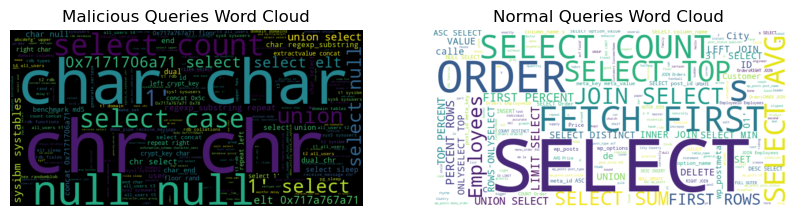

In [12]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(malicious_wordcloud, interpolation='bilinear')
plt.title('Malicious Queries Word Cloud')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(normal_wordcloud, interpolation='bilinear')
plt.title('Normal Queries Word Cloud')
plt.axis('off')

plt.show()

In [15]:
malicious_words = ' '.join(malicious_queries).split()
word_freq = Counter(malicious_words)
common_words = word_freq.most_common(20)

words, counts = zip(*common_words)

In [17]:
words = list(words)
counts = list(counts)

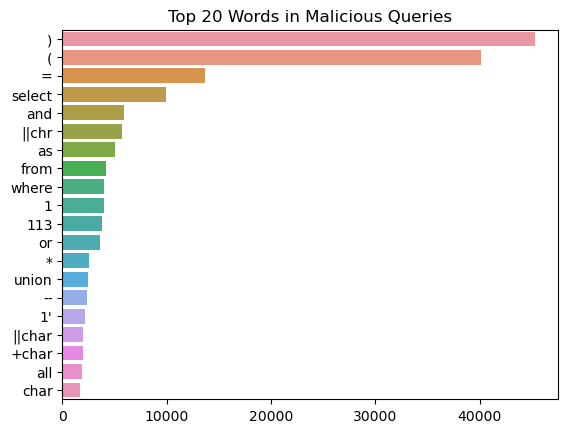

In [19]:
sns.barplot(x=counts, y=words)
plt.title('Top 20 Words in Malicious Queries')
plt.show()

Data Preparation for Model Implementation

In [22]:
X = df['Query']
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

In [26]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [28]:
max_length = 100 
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

In [30]:
print(f"Shape of X_train_pad: {X_train_pad.shape}")
print(f"Shape of X_test_pad: {X_test_pad.shape}")

Shape of X_train_pad: (24735, 100)
Shape of X_test_pad: (6184, 100)


CNN Model Building

In [33]:
model_cnn = Sequential()
model_cnn.add(Embedding(input_dim=5000, output_dim=128))  # Removed input_length
model_cnn.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Flatten())
model_cnn.add(Dense(10, activation='relu'))
model_cnn.add(Dense(1, activation='sigmoid'))  # Binary classification

In [35]:
model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [37]:
history_cnn = model_cnn.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9187 - loss: 0.1888 - val_accuracy: 0.9947 - val_loss: 0.0252
Epoch 2/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9956 - loss: 0.0185 - val_accuracy: 0.9951 - val_loss: 0.0212
Epoch 3/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9964 - loss: 0.0165 - val_accuracy: 0.9947 - val_loss: 0.0203
Epoch 4/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9977 - loss: 0.0125 - val_accuracy: 0.9935 - val_loss: 0.0239
Epoch 5/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9983 - loss: 0.0111 - val_accuracy: 0.9901 - val_loss: 0.0337


Model Evaluation

In [40]:
cnn_loss, cnn_accuracy = model_cnn.evaluate(X_test_pad, y_test)
print(f"CNN Test Accuracy: {cnn_accuracy:.4f}")

194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9912 - loss: 0.0337
CNN Test Accuracy: 0.9929


LSTM Model